<a href="https://colab.research.google.com/github/Pravallika-B6/AI_Powered_Intelligent_Traffic_Safety_and_Emergency_Response_System/blob/main/CAR_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import importlib
import subprocess
import sys

for pip_name, module_name in [("opencv-python-headless", "cv2"), ("seaborn", "seaborn"),
                              ("scikit-learn", "sklearn"), ("pandas", "pandas"),
                              ("matplotlib", "matplotlib"), ("tqdm", "tqdm")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


import os
import gc
import json
import time
import random
import shutil
import datetime
from collections import deque

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, regularizers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
                             classification_report, confusion_matrix, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score,
                             precision_recall_fscore_support)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.keras.utils.set_random_seed(SEED)  # sets all three seeds at once on recent versions
except AttributeError:
    pass
# NOTE: some GPU operations are non-deterministic, so tiny run-to-run differences can still occur.

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
if not gpus:
    print("WARNING: No GPU found. Training will work on CPU but will be slow. "
          "Use Runtime > Change runtime type > T4 GPU.")
else:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except RuntimeError as e:
            print("Could not set memory growth (already initialised):", e)



TensorFlow version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/datasets/data3'

BASE_DIR = path
train_dir = os.path.join(BASE_DIR, 'train')
val_dir = os.path.join(BASE_DIR, 'val')
test_dir = os.path.join(BASE_DIR, 'test')
SPLIT_DIRS = {"train": train_dir, "val": val_dir, "test": test_dir}

# Class order defines the label index: 0 = Non_Accident, 1 = Accident (used everywhere).
classes = ["Non Accident", "Accident"]
CLASS_TO_IDX = {c: i for i, c in enumerate(classes)}
assert classes == ["Non Accident", "Accident"], "Class names/order must not be changed."
assert CLASS_TO_IDX == {"Non Accident": 0, "Accident": 1}
NON_ACCIDENT, ACCIDENT = 0, 1

# Expected counts (from the project description) - used only to warn about mismatches.
EXPECTED_COUNTS = {
    "train": {"Accident": 370, "Non Accident": 422},
    "val":   {"Accident": 46,  "Non Accident": 52},
    "test":  {"Accident": 47,  "Non Accident": 53},
}

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff')
IMG_SIZE = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE = 16

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---- Model / training settings (all configurable) ----
BACKBONE_TRAINABLE = False      # backbone is frozen for initial training
FINE_TUNE_LAST_N = 30           # number of FINAL EfficientNet-B0 layers considered for unfreezing (BN stays frozen)
INITIAL_LR = 5e-4               # modest LR for the new CAR-Net modules (frozen backbone)
FINE_TUNE_LR = 1e-5             # much smaller LR for fine-tuning
INITIAL_EPOCHS = 30
FINE_TUNE_EPOCHS = 20
WEIGHT_DECAY = 1e-4             # L2 regularisation (small dataset -> regularise)

# ---- Alert settings ----
ACCIDENT_THRESHOLD = 0.80
REQUIRED_CONSECUTIVE_HITS = 3

# ---- Output folder (inside Google Drive so nothing is lost when Colab disconnects) ----
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_car_net.keras')
FINAL_MODEL_PATH = os.path.join(OUTPUT_DIR, 'final_car_net.keras')
CLASS_NAMES_PATH = os.path.join(OUTPUT_DIR, 'class_names.json')
HISTORY_PATH = os.path.join(OUTPUT_DIR, 'training_history.json')
print("Outputs will be saved to:", OUTPUT_DIR)

Outputs will be saved to: /content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs


In [ ]:
def verify_directories():
    """Raise a clear error if any required directory is missing."""
    missing = []
    if not os.path.isdir(BASE_DIR):
        missing.append(BASE_DIR)
    for split_name, split_dir in SPLIT_DIRS.items():
        if not os.path.isdir(split_dir):
            missing.append(split_dir)
            continue
        for c in classes:
            cdir = os.path.join(split_dir, c)
            if not os.path.isdir(cdir):
                missing.append(cdir)
    if missing:
        raise FileNotFoundError("Missing dataset directories:\n  " + "\n  ".join(missing))
    print("All dataset directories exist.")


def list_images(folder):
    """Return (valid_image_paths, unsupported_file_paths) for a folder."""
    valid, unsupported = [], []
    for fname in sorted(os.listdir(folder)):
        fpath = os.path.join(folder, fname)
        if not os.path.isfile(fpath):
            continue
        if fname.lower().endswith(VALID_EXTENSIONS):
            valid.append(fpath)
        else:
            unsupported.append(fpath)
    return valid, unsupported


verify_directories()

file_index = {}        # (split, class) -> list of valid image paths
unsupported_files = []
corrupted_files = []

for split_name, split_dir in SPLIT_DIRS.items():
    for c in classes:
        cdir = os.path.join(split_dir, c)
        valid, unsupported = list_images(cdir)
        if len(valid) == 0:
            raise ValueError(f"Empty class folder (no valid images): {cdir}")
        unsupported_files.extend(unsupported)
        good = []
        for fp in tqdm(valid, desc=f"Checking {split_name}/{c}", leave=False):
            img = cv2.imread(fp)  # returns None if the file cannot be decoded
            if img is None or img.size == 0:
                corrupted_files.append(fp)
            else:
                good.append(fp)
        file_index[(split_name, c)] = good

print("\n--- Dataset verification report ---")
if unsupported_files:
    print(f"Unsupported files found ({len(unsupported_files)}):")
    for f in unsupported_files:
        print("   UNSUPPORTED:", f)
else:
    print("No unsupported files found.")
if corrupted_files:
    print(f"CORRUPTED images found ({len(corrupted_files)}) - they will be EXCLUDED from the arrays:")
    for f in corrupted_files:
        print("   CORRUPTED:", f)
else:
    print("No corrupted images found.")

All dataset directories exist.


Checking train/Non Accident:   0%|          | 0/422 [00:00<?, ?it/s]

Checking train/Accident:   0%|          | 0/370 [00:00<?, ?it/s]

Checking val/Non Accident:   0%|          | 0/52 [00:00<?, ?it/s]

Checking val/Accident:   0%|          | 0/46 [00:00<?, ?it/s]

Checking test/Non Accident:   0%|          | 0/53 [00:00<?, ?it/s]

Checking test/Accident:   0%|          | 0/47 [00:00<?, ?it/s]


--- Dataset verification report ---
No unsupported files found.
No corrupted images found.


class  Non Accident  Accident
split                        
test             53        47
train           422       370
val              52        46

Totals per class:
 class
Accident        463
Non Accident    527
Name: count, dtype: int64
Total images: 990


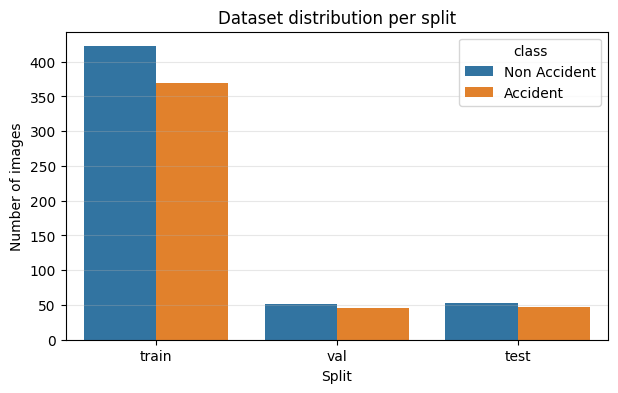

In [ ]:
rows = []
for split_name in SPLIT_DIRS:
    for c in classes:
        rows.append({"split": split_name, "class": c, "count": len(file_index[(split_name, c)])})
dist_df = pd.DataFrame(rows)
print(dist_df.pivot(index="split", columns="class", values="count")[classes])

for split_name in SPLIT_DIRS:
    for c in classes:
        actual = len(file_index[(split_name, c)])
        expected = EXPECTED_COUNTS[split_name][c]
        if actual != expected:
            print(f"WARNING: {split_name}/{c} has {actual} valid images, expected {expected}.")

totals = dist_df.groupby("class")["count"].sum()
print("\nTotals per class:\n", totals)
print("Total images:", int(totals.sum()))

plt.figure(figsize=(7, 4))
sns.barplot(data=dist_df, x="split", y="count", hue="class")
plt.title("Dataset distribution per split")
plt.xlabel("Split")
plt.ylabel("Number of images")
plt.grid(axis="y", alpha=0.3)
plt.show()

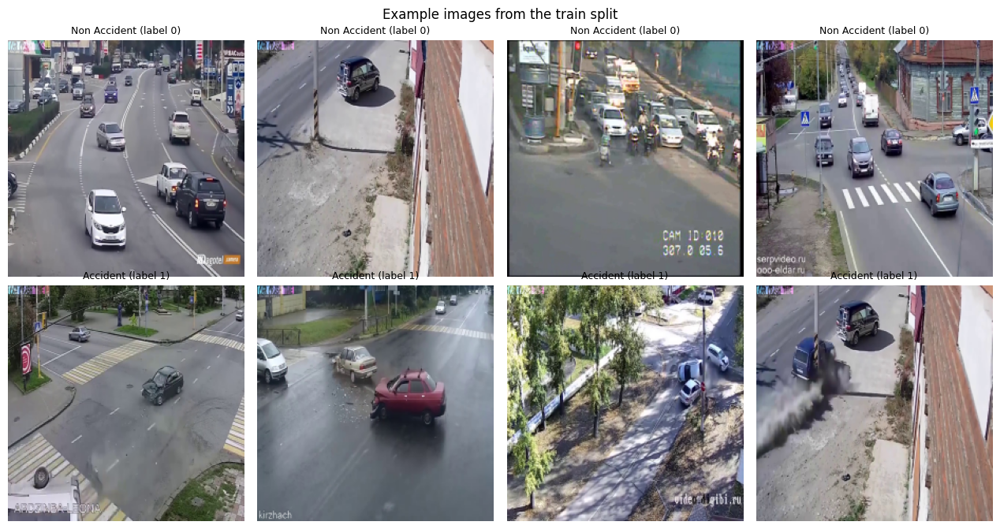

In [ ]:
def load_rgb_image(image_path):
    """Read an image with OpenCV, convert BGR -> RGB and resize to 224x224 (uint8, for display or processing)."""
    if not os.path.isfile(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    bgr = cv2.imread(image_path)                      # OpenCV loads as BGR
    if bgr is None or bgr.size == 0:
        raise ValueError(f"Cannot read image (corrupted or unsupported): {image_path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)        # EfficientNet expects RGB channel order
    rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # fixed input size
    return rgb


def show_examples(n_per_class=4, split_name="train"):
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(3.2 * n_per_class, 3.4 * len(classes)))
    for r, c in enumerate(classes):
        files = file_index[(split_name, c)]
        picks = random.sample(files, min(n_per_class, len(files)))
        for k in range(n_per_class):
            ax = axes[r, k]
            ax.axis("off")
            if k < len(picks):
                ax.imshow(load_rgb_image(picks[k]))
                ax.set_title(f"{c} (label {CLASS_TO_IDX[c]})", fontsize=9)
    plt.suptitle(f"Example images from the {split_name} split")
    plt.tight_layout()
    plt.show()


show_examples()

In [ ]:
def preprocess_image(image_path, label=None):
    """
    Full preprocessing pipeline used for training, validation, testing and inference.
    Returns (processed_image, label).
    """
    rgb = load_rgb_image(image_path)          # 1) read (OpenCV) + BGR->RGB + resize to 224x224
    img = rgb.astype(np.float32)              # 2) float32: required by the network and by preprocess_input
    # 3) EfficientNet preprocessing. In tf.keras the EfficientNet-B0 model contains its own Rescaling/Normalization
    #    layers, so preprocess_input keeps pixel values in [0, 255] (it is intentionally a pass-through).
    #    We still call it so the code stays correct if the backbone is ever swapped.
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    img = np.asarray(img, dtype=np.float32)
    if img.shape != INPUT_SHAPE:
        raise ValueError(f"Shape mismatch for {image_path}: got {img.shape}, expected {INPUT_SHAPE}")
    return img, label
    # No test-time augmentation is applied anywhere in this project.

In [ ]:
def load_split(split_name):
    """Load all images of one split (existing folder split is used; splits are never mixed)."""
    X, y, paths, failed = [], [], [], []
    for c in classes:
        for fp in tqdm(file_index[(split_name, c)], desc=f"Loading {split_name}/{c}", leave=False):
            try:
                img, lab = preprocess_image(fp, CLASS_TO_IDX[c])
                X.append(img)
                y.append(lab)
                paths.append(fp)
            except Exception as e:  # report, do not hide
                failed.append((fp, str(e)))
                print(f"FAILED to load {fp}: {e}")
    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int32)
    return X, y, np.array(paths), failed


X_train, y_train, train_paths, f1_ = load_split("train")
X_val, y_val, val_paths, f2_ = load_split("val")
X_test, y_test, test_paths, f3_ = load_split("test")

# ---- Sanity checks (shape mismatch / NaN) ----
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    assert X.shape[1:] == INPUT_SHAPE, f"{name}: bad image shape {X.shape}"
    assert len(X) == len(y), f"{name}: images/labels length mismatch"
    assert not np.isnan(X).any(), f"{name}: NaN values found in images"
    assert set(np.unique(y)).issubset({0, 1}), f"{name}: unexpected labels"

# Make sure no file appears in two splits
all_paths = np.concatenate([train_paths, val_paths, test_paths])
assert len(set(all_paths)) == len(all_paths), "Some image path appears in more than one split!"

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples   :", len(X_test))
print("\nClass distribution (0 = Non_Accident, 1 = Accident):")
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = np.bincount(y, minlength=2)
    print(f"  {name:5s}: Non_Accident={counts[0]}, Accident={counts[1]}")

Loading train/Non Accident:   0%|          | 0/422 [00:00<?, ?it/s]

Loading train/Accident:   0%|          | 0/370 [00:00<?, ?it/s]

Loading val/Non Accident:   0%|          | 0/52 [00:00<?, ?it/s]

Loading val/Accident:   0%|          | 0/46 [00:00<?, ?it/s]

Loading test/Non Accident:   0%|          | 0/53 [00:00<?, ?it/s]

Loading test/Accident:   0%|          | 0/47 [00:00<?, ?it/s]

Training samples  : 792
Validation samples: 98
Testing samples   : 100

Class distribution (0 = Non_Accident, 1 = Accident):
  train: Non_Accident=422, Accident=370
  val  : Non_Accident=52, Accident=46
  test : Non_Accident=53, Accident=47


In [ ]:
class_weights_array = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(class_weights_array[0]), 1: float(class_weights_array[1])}
print("Class weights (computed from training labels only):")
print(f"  0 (Non_Accident): {class_weight_dict[0]:.4f}")
print(f"  1 (Accident)    : {class_weight_dict[1]:.4f}")

Class weights (computed from training labels only):
  0 (Non_Accident): 0.9384
  1 (Accident)    : 1.0703


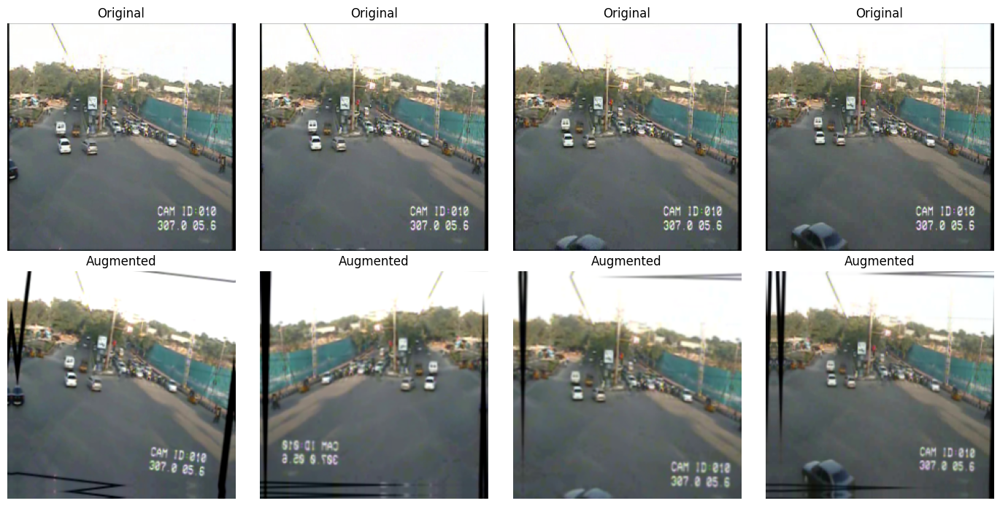

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02),
    layers.RandomZoom((-0.10, 0.10)),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
], name="train_augmentation")


def make_dataset(X, y, training):
    """Create a tf.data pipeline. Augmentation is applied ONLY when training=True."""
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(lambda imgs, labs: (data_augmentation(imgs, training=True), labs),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test, y_test, training=False)
train_eval_ds = make_dataset(X_train, y_train, training=False)   # un-augmented, for final evaluation only

# Visual check of augmentation
sample_batch = X_train[:4]
aug_batch = data_augmentation(sample_batch, training=True).numpy()
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(np.clip(sample_batch[i], 0, 255).astype(np.uint8)); axes[0, i].set_title("Original"); axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(aug_batch[i], 0, 255).astype(np.uint8)); axes[1, i].set_title("Augmented"); axes[1, i].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
def build_backbone():
    """EfficientNet-B0 (ImageNet weights, no classification head). Output: (B, 7, 7, 1280) feature maps."""
    try:
        backbone = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                                        input_shape=INPUT_SHAPE)
    except Exception as e:
        raise RuntimeError("Could not load EfficientNet-B0 ImageNet weights (check the internet connection "
                           f"of the Colab runtime): {e}")
    backbone.trainable = BACKBONE_TRAINABLE   # frozen at the start; changed during fine-tuning
    return backbone


_tmp_backbone = build_backbone()
print("Backbone output shape:", _tmp_backbone.output_shape, "| layers:", len(_tmp_backbone.layers),
      "| trainable:", _tmp_backbone.trainable)
del _tmp_backbone

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone output shape: (None, 7, 7, 1280) | layers: 238 | trainable: False


In [ ]:
def conv_bn_relu(x, filters, kernel_size, name):
    """Conv -> BatchNorm -> ReLU building block (L2-regularised, no bias because BN follows)."""
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    return x


def multi_scale_feature_extraction(x, branch_filters=64, out_filters=128, dropout=0.2, name="msfe"):
    """
    Genuine multi-scale module: three parallel branches with different receptive fields.
    Tensor flow (224x224 input):
        x                      : (B, 7, 7, 1280)  backbone feature map
        bottleneck 1x1         : (B, 7, 7, 128)   cheap channel reduction (keeps 3x3/5x5 convs small)
        branch 1x1 / 3x3 / 5x5 : (B, 7, 7, 64) each  -> local detail / medium context / wide context
        concatenation          : (B, 7, 7, 192)
        projection 1x1         : (B, 7, 7, 128)
    """
    reduced = conv_bn_relu(x, 128, 1, f"{name}_bottleneck")
    b1 = conv_bn_relu(reduced, branch_filters, 1, f"{name}_b1x1")   # point-wise (small receptive field)
    b3 = conv_bn_relu(reduced, branch_filters, 3, f"{name}_b3x3")   # medium receptive field
    b5 = conv_bn_relu(reduced, branch_filters, 5, f"{name}_b5x5")   # large receptive field
    cat = layers.Concatenate(axis=-1, name=f"{name}_concat")([b1, b3, b5])
    out = conv_bn_relu(cat, out_filters, 1, f"{name}_project")
    out = layers.SpatialDropout2D(dropout, name=f"{name}_dropout")(out)
    return out

In [ ]:
@tf.keras.utils.register_keras_serializable(package="CARNet")
class MapGating(layers.Layer):
    """
    Residual spatial weighting: output = features * (1 + map).
    features: (B, H, W, C), map: (B, H, W, 1) in [0, 1]. The "1 +" keeps the original features
    (so a near-zero map cannot erase information) while still emphasising high-map regions.
    """
    def call(self, inputs):
        feat, spatial_map = inputs
        return feat * (1.0 + spatial_map)

    def compute_output_shape(self, input_shape):
        return input_shape[0]


def spatial_region_feature_generator(x, name="srfg"):
    """
    Learns WHERE to look (vehicle / collision / damaged-vehicle / road-interaction regions) without any
    bounding boxes: a small conv stack predicts a 1-channel spatial attention map from the features.
        x            : (B, 7, 7, 128)
        attention    : (B, 7, 7, 1)   sigmoid weights
        region feats : (B, 7, 7, 128) = x * (1 + attention)
    """
    a = conv_bn_relu(x, 32, 3, f"{name}_att")
    attention = layers.Conv2D(1, 1, activation="sigmoid", name=f"{name}_attention_map")(a)
    weighted = MapGating(name=f"{name}_weighting")([x, attention])
    weighted = layers.BatchNormalization(name=f"{name}_out_bn")(weighted)
    return weighted, attention

In [ ]:
@tf.keras.utils.register_keras_serializable(package="CARNet")
class PairwiseCollisionRelation(layers.Layer):
    """
    Models relations between spatial regions (the "Vehicle A <-> Vehicle B" idea) in a compact way.

    1) Tokens   : the (H, W, C) map becomes N = H*W region tokens of size C (7x7 -> N = 49).
    2) Pairs    : for every ordered pair (i, j) a small pair feature is built (dimension d = pair_dim = 32):
                      pair_ij = ReLU( A(x_i) + B(x_j) + C(x_i) * C(x_j) )
                  A(x_i)+B(x_j) is a directional term (i acts on j) and C(x_i)*C(x_j) is a symmetric
                  interaction term (how strongly the two regions "agree/overlap").
                  Size: (B, N, N, d) = (B, 49, 49, 32) -> small enough for CPU/GPU, because we use a compact d
                  instead of full C=128 channels for every pair.
    3) Relation score : s_ij = Dense(1)(pair_ij); alpha_ij = softmax over j (which partner regions matter for i).
    4) Aggregation    : r_i = sum_j alpha_ij * pair_ij   -> (B, N, d)
    5) Output         : project r_i back to C, add to the token (residual), LayerNorm, reshape to (B, H, W, C).
    """
    def __init__(self, pair_dim=32, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.pair_dim = pair_dim
        self.dropout_rate = dropout
        self.proj_a = layers.Dense(pair_dim, use_bias=False, name="proj_a")
        self.proj_b = layers.Dense(pair_dim, use_bias=False, name="proj_b")
        self.proj_c = layers.Dense(pair_dim, use_bias=False, name="proj_c")
        self.score = layers.Dense(1, name="pair_score")
        self.drop = layers.Dropout(dropout)
        self.norm = layers.LayerNormalization(name="relation_norm")

    def build(self, input_shape):
        h, w, c = input_shape[1], input_shape[2], input_shape[3]
        if h is None or w is None or c is None:
            raise ValueError("PairwiseCollisionRelation needs a fully defined (H, W, C) input shape.")
        self.h, self.w, self.c = int(h), int(w), int(c)
        self.n = self.h * self.w
        # Output projection depends on C, so it is created here.
        self.out_proj = layers.Dense(self.c, name="relation_out_proj")
        tok = (None, self.n, self.c)
        self.proj_a.build(tok)
        self.proj_b.build(tok)
        self.proj_c.build(tok)
        self.score.build((None, self.n, self.n, self.pair_dim))
        self.out_proj.build((None, self.n, self.pair_dim))
        self.norm.build(tok)
        super().build(input_shape)

    def call(self, x, training=None):
        tokens = tf.reshape(x, (-1, self.n, self.c))                          # (B, N, C)
        a = self.proj_a(tokens)                                               # (B, N, d)
        b = self.proj_b(tokens)                                               # (B, N, d)
        c = self.proj_c(tokens)                                               # (B, N, d)
        pair = (tf.expand_dims(a, 2)                                          # (B, N, 1, d)  region i
                + tf.expand_dims(b, 1)                                        # (B, 1, N, d)  region j
                + tf.expand_dims(c, 2) * tf.expand_dims(c, 1))                # interaction term
        pair = tf.nn.relu(pair)                                               # (B, N, N, d)
        alpha = tf.nn.softmax(self.score(pair), axis=2)                       # (B, N, N, 1) weights over partners j
        relation = tf.reduce_sum(alpha * pair, axis=2)                        # (B, N, d)  aggregated relation
        relation = self.out_proj(relation)                                    # (B, N, C)
        relation = self.drop(relation, training=training)
        out = self.norm(tokens + relation)                                    # residual + normalisation
        return tf.reshape(out, (-1, self.h, self.w, self.c))                  # (B, H, W, C)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"pair_dim": self.pair_dim, "dropout": self.dropout_rate})
        return cfg

In [ ]:
def collision_risk_map_generator(x, name="crmg"):
    """
    Produces a learned collision-risk map from the relation-enhanced features.
        x         : (B, 7, 7, 128)
        risk map  : (B, 7, 7, 1) sigmoid  (named 'collision_risk_map')
        weighted  : (B, 7, 7, 128) = x * (1 + risk)
    IMPORTANT: there are no pixel-level labels. The map is trained ONLY through the image-level
    Accident/Non-Accident loss, so it is an internal attention-like activation, not a ground-truth mask.
    """
    r = conv_bn_relu(x, 64, 3, f"{name}_a")
    r = conv_bn_relu(r, 32, 3, f"{name}_b")
    risk_map = layers.Conv2D(1, 1, activation="sigmoid", name="collision_risk_map")(r)
    weighted = MapGating(name=f"{name}_weighting")([x, risk_map])
    weighted = layers.BatchNormalization(name=f"{name}_out_bn")(weighted)
    return weighted, risk_map

In [ ]:
def relation_aware_feature_fusion(ms_feat, region_feat, relation_feat, risk_feat, risk_map,
                                  out_filters=128, dropout=0.2, name="fusion"):
    """
    Real fusion stage (not just concatenate-and-classify).
        inputs (each (B,7,7,128), risk_map (B,7,7,1)) -> concat (B,7,7,513)
        1x1 projection to 128 channels (learns how to mix the four sources)
        sigmoid channel gate computed from ALL sources (learns which source matters per channel)
        gated = projection * gate
        refinement with a depthwise-separable 3x3 conv (+ residual)
    """
    cat = layers.Concatenate(axis=-1, name=f"{name}_concat")([ms_feat, region_feat, relation_feat, risk_feat, risk_map])
    proj = conv_bn_relu(cat, out_filters, 1, f"{name}_proj")
    gate = layers.Conv2D(out_filters, 1, activation="sigmoid", name=f"{name}_gate")(cat)
    gated = layers.Multiply(name=f"{name}_gated")([proj, gate])
    refined = layers.SeparableConv2D(out_filters, 3, padding="same", use_bias=False,
                                     depthwise_regularizer=regularizers.l2(WEIGHT_DECAY),
                                     pointwise_regularizer=regularizers.l2(WEIGHT_DECAY),
                                     name=f"{name}_sepconv")(gated)
    refined = layers.BatchNormalization(name=f"{name}_sep_bn")(refined)
    refined = layers.Activation("relu", name=f"{name}_sep_relu")(refined)
    out = layers.Add(name=f"{name}_residual")([gated, refined])
    out = layers.SpatialDropout2D(dropout, name=f"{name}_dropout")(out)
    return out

In [ ]:
def classification_head(x, name="head"):
    """GAP -> Dense -> ReLU -> Dropout -> Dense(2, softmax). Output index 0 = Non_Accident, 1 = Accident."""
    x = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name=f"{name}_dense")(x)
    x = layers.Dropout(0.4, name=f"{name}_dropout")(x)
    return layers.Dense(2, activation="softmax", name="predictions")(x)


def build_car_net(use_multiscale=True, use_spatial=True, use_relation=True, use_risk=True, use_fusion=True,
                  name="CAR_Net"):
    """
    All flags True  -> full CAR-Net.
    All flags False -> baseline EfficientNet-B0 + GAP + MLP (ablation Model 1).
    Modules are added cumulatively (each requires the previous ones).
    """
    if use_spatial and not use_multiscale: raise ValueError("use_spatial requires use_multiscale")
    if use_relation and not use_spatial: raise ValueError("use_relation requires use_spatial")
    if use_risk and not use_relation: raise ValueError("use_risk requires use_relation")
    if use_fusion and not use_risk: raise ValueError("use_fusion requires use_risk")

    backbone = build_backbone()
    inputs = layers.Input(shape=INPUT_SHAPE, name="input_image")
    # training=False keeps the backbone's BatchNorm in inference mode (important for small datasets).
    feat = backbone(inputs, training=False)                                   # (B, 7, 7, 1280)

    ms = region = rel = risk_feat = risk_map = None
    if use_multiscale:
        ms = multi_scale_feature_extraction(feat)                             # (B, 7, 7, 128)
        feat = ms
    if use_spatial:
        region, _ = spatial_region_feature_generator(feat)                    # (B, 7, 7, 128)
        feat = region
    if use_relation:
        rel = PairwiseCollisionRelation(pair_dim=32, dropout=0.1, name="pairwise_collision_relation")(feat)
        feat = rel                                                            # (B, 7, 7, 128)
    if use_risk:
        risk_feat, risk_map = collision_risk_map_generator(feat)              # (B,7,7,128), (B,7,7,1)
        feat = risk_feat
    if use_fusion:
        feat = relation_aware_feature_fusion(ms, region, rel, risk_feat, risk_map)   # (B, 7, 7, 128)

    outputs = classification_head(feat)                                       # (B, 2)
    return tf.keras.Model(inputs, outputs, name=name)

In [ ]:
def count_params(model):
    total = int(model.count_params())
    trainable = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    return total, trainable, total - trainable


def print_param_report(model):
    total, trainable, non_trainable = count_params(model)
    print(f"Total parameters        : {total:,}")
    print(f"Trainable parameters    : {trainable:,}")
    print(f"Non-trainable parameters: {non_trainable:,}")
    print(f"Approx. model size (float32 weights): {total * 4 / (1024 ** 2):.2f} MB")


model = build_car_net()
model.summary()
print_param_report(model)

# Quick forward-pass shape check on real data (catches shape mismatches early)
_probe = model(X_train[:2], training=False).numpy()
assert _probe.shape == (2, 2), f"Unexpected output shape: {_probe.shape}"
assert np.allclose(_probe.sum(axis=1), 1.0, atol=1e-4), "Softmax outputs do not sum to 1"
print("Forward-pass check OK. Output shape:", _probe.shape)

Model: "CAR_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_image[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_bottleneck_co… │ (None, 7, 7, 128) │    163,840 │ efficientnetb0[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_bottleneck_bn  │ (None, 7, 7, 128) │        512 │ msfe_bottleneck_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_bottleneck_re… │ (None, 7, 7, 128) │          0 │ msfe_bottleneck_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b1x1_conv      │ (None, 7, 7, 64)  │      8,192 │ msfe_bottleneck_… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b3x3_conv      │ (None, 7, 7, 64)  │     73,728 │ msfe_bottleneck_… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b5x5_conv      │ (None, 7, 7, 64)  │    204,800 │ msfe_bottleneck_… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b1x1_bn        │ (None, 7, 7, 64)  │        256 │ msfe_b1x1_conv[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b3x3_bn        │ (None, 7, 7, 64)  │        256 │ msfe_b3x3_conv[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b5x5_bn        │ (None, 7, 7, 64)  │        256 │ msfe_b5x5_conv[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b1x1_relu      │ (None, 7, 7, 64)  │          0 │ msfe_b1x1_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b3x3_relu      │ (None, 7, 7, 64)  │          0 │ msfe_b3x3_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_b5x5_relu      │ (None, 7, 7, 64)  │          0 │ msfe_b5x5_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_concat         │ (None, 7, 7, 192) │          0 │ msfe_b1x1_relu[0… │
│ (Concatenate)       │                   │            │ msfe_b3x3_relu[0… │
│                     │                   │            │ msfe_b5x5_relu[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ msfe_project_conv   │ (None, 7, 7, 128) │     24,576 │ msfe_concat[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,840,712 (18.47 MB)

 Trainable params: 788,965 (3.01 MB)

 Non-trainable params: 4,051,747 (15.46 MB)

Total parameters        : 4,840,712
Trainable parameters    : 788,965
Non-trainable parameters: 4,051,747
Approx. model size (float32 weights): 18.47 MB
Forward-pass check OK. Output shape: (2, 2)


In [ ]:
class AccidentPrecision(tf.keras.metrics.Precision):
    """Precision of class 1 (Accident) for a 2-unit softmax output and sparse integer labels."""
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, (-1,)), tf.float32)
        return super().update_state(y_true, y_pred[:, 1], sample_weight)


class AccidentRecall(tf.keras.metrics.Recall):
    """Recall of class 1 (Accident) for a 2-unit softmax output and sparse integer labels."""
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, (-1,)), tf.float32)
        return super().update_state(y_true, y_pred[:, 1], sample_weight)


CUSTOM_OBJECTS = {"PairwiseCollisionRelation": PairwiseCollisionRelation, "MapGating": MapGating}


def compile_model(m, learning_rate):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
                 AccidentPrecision(name="precision"),
                 AccidentRecall(name="recall")],
    )


compile_model(model, INITIAL_LR)
print("Model compiled with Adam, lr =", INITIAL_LR)

Model compiled with Adam, lr = 0.0005


In [ ]:
def make_callbacks(checkpoint_path=None, initial_value_threshold=None, patience_es=8, patience_lr=3):
    cbs = [
        tf.keras.callbacks.TerminateOnNaN(),   # stops training immediately if the loss becomes NaN
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience_es,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=patience_lr,
                                             min_lr=1e-7, verbose=1),
    ]
    if checkpoint_path is not None:
        kwargs = dict(filepath=checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1)
        if initial_value_threshold is not None:
            kwargs["initial_value_threshold"] = initial_value_threshold
        cbs.append(tf.keras.callbacks.ModelCheckpoint(**kwargs))   # prints a message whenever it saves
    return cbs


def check_history_for_nan(hist):
    for k, v in hist.history.items():
        if np.isnan(np.array(v, dtype=float)).any():
            raise RuntimeError(f"NaN detected in training history key '{k}'. Lower the learning rate or check the data.")


print("BACKBONE_TRAINABLE =", BACKBONE_TRAINABLE, "(backbone frozen for initial training)")

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(BEST_MODEL_PATH),
    verbose=1,
)
check_history_for_nan(history_stage1)
best_val_loss_stage1 = float(np.min(history_stage1.history["val_loss"]))
print(f"\nStage 1 finished. Best val_loss = {best_val_loss_stage1:.4f}. Best model saved at: {BEST_MODEL_PATH}")

BACKBONE_TRAINABLE = False (backbone frozen for initial training)
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.5205 - loss: 0.8562 - precision: 0.4956 - recall: 0.5880
Epoch 1: val_loss improved from None to 0.76022, saving model to /content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs/best_car_net.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs/best_car_net.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.5795 - loss: 0.8051 - precision: 0.5476 - recall: 0.5757 - val_accuracy: 0.6327 - val_loss: 0.7602 - val_precision: 0.5625 - val_recall: 0.9783 - learning_rate: 5.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7146 - loss: 0.6808 - precision: 0.6959 - recall: 0.7037
Epoch 2: val_loss improved from 0.76022 to 0.68985, saving model to /content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs/best_car_net.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebook

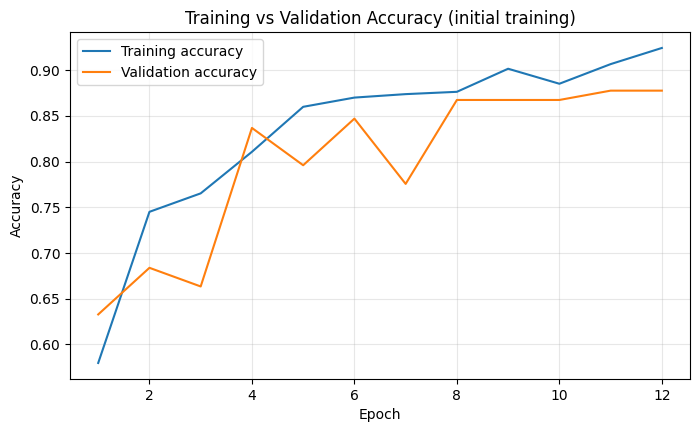

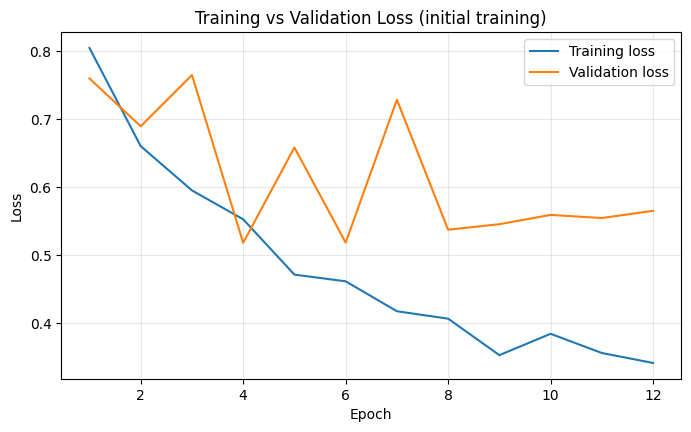

How to interpret overfitting:
 - Training accuracy keeps rising while validation accuracy stalls/falls  -> overfitting.
 - Training loss keeps falling while validation loss starts to RISE        -> overfitting (EarlyStopping reacts to this).
 - Both curves close together and both good                                -> healthy generalisation.
 - Both curves poor                                                        -> underfitting (model/features/LR issue).
With only 990 images, a gap of a few percent is normal; a large and growing gap is the warning sign.


In [ ]:
def plot_history(hist_dict, split_epoch=None, title_suffix=""):
    epochs = range(1, len(hist_dict["loss"]) + 1)
    for metric, label in [("accuracy", "Accuracy"), ("loss", "Loss")]:
        plt.figure(figsize=(8, 4.5))
        plt.plot(epochs, hist_dict[metric], label=f"Training {label.lower()}")
        plt.plot(epochs, hist_dict[f"val_{metric}"], label=f"Validation {label.lower()}")
        if split_epoch is not None:
            plt.axvline(split_epoch + 0.5, color="gray", linestyle="--", label="Fine-tuning starts")
        plt.title(f"Training vs Validation {label}{title_suffix}")
        plt.xlabel("Epoch")
        plt.ylabel(label)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


plot_history(history_stage1.history, title_suffix=" (initial training)")

print("""How to interpret overfitting:
 - Training accuracy keeps rising while validation accuracy stalls/falls  -> overfitting.
 - Training loss keeps falling while validation loss starts to RISE        -> overfitting (EarlyStopping reacts to this).
 - Both curves close together and both good                                -> healthy generalisation.
 - Both curves poor                                                        -> underfitting (model/features/LR issue).
With only 990 images, a gap of a few percent is normal; a large and growing gap is the warning sign.""")

Backbone layers total: 238 | final layers considered: 30 | layers actually unfrozen (non-BN): 23
Total parameters        : 4,840,712
Trainable parameters    : 2,272,325
Non-trainable parameters: 2,568,387
Approx. model size (float32 weights): 18.47 MB
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.8602 - loss: 0.4826 - precision: 0.8703 - recall: 0.8304
Epoch 1: val_loss did not improve from 0.51827
50/50 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8674 - loss: 0.4562 - precision: 0.8754 - recall: 0.8351 - val_accuracy: 0.8469 - val_loss: 0.5601 - val_precision: 0.7719 - val_recall: 0.9565 - learning_rate: 1.0000e-05
Epoch 2/20
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8644 - loss: 0.4266 - precision: 0.8794 - recall: 0.8264
Epoch 2: val_loss did not improve from 0.51827
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.8763 - loss: 0.4224 - precision: 0.8799 - recall: 0.8514 - val_accuracy: 0.8469 - val_loss: 0.5650 - val_precision: 0.7627 - v

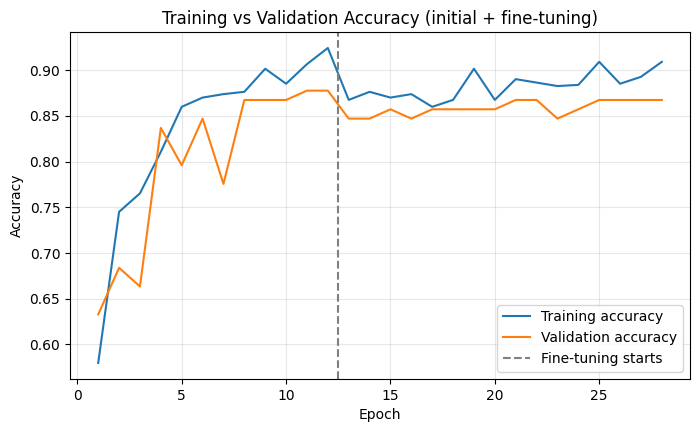

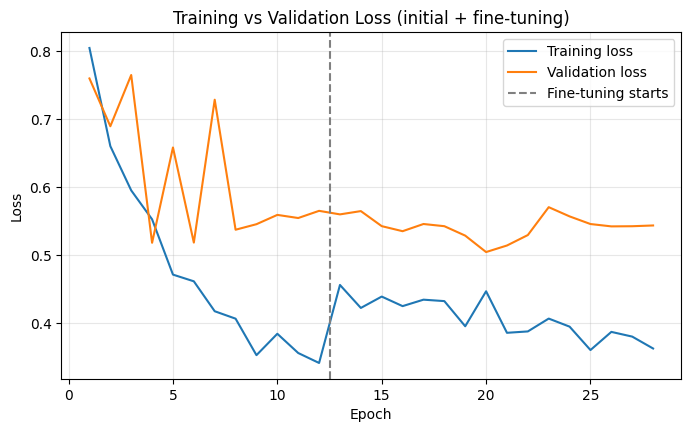

In [ ]:
def get_backbone(m):
    """Return the nested EfficientNet-B0 sub-model of a CAR-Net / baseline model."""
    for layer in m.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise RuntimeError("Backbone sub-model not found inside the model.")


def load_car_net_model(model_path):
    if not os.path.isfile(model_path):
        raise FileNotFoundError(f"Model checkpoint not found: {model_path}. Train first (section 20) or check the path.")
    return tf.keras.models.load_model(model_path, custom_objects=CUSTOM_OBJECTS, compile=False)


def unfreeze_last_layers(m, last_n):
    """Unfreeze ONLY the last `last_n` backbone layers; BatchNorm layers and all earlier layers stay frozen."""
    bb = get_backbone(m)
    bb.trainable = True
    for layer in bb.layers:
        layer.trainable = False                       # start from fully frozen
    unfrozen = 0
    for layer in bb.layers[-last_n:]:
        if isinstance(layer, layers.BatchNormalization):
            continue                                  # keep BN frozen (stable statistics on a small dataset)
        layer.trainable = True
        unfrozen += 1
    print(f"Backbone layers total: {len(bb.layers)} | final layers considered: {last_n} | "
          f"layers actually unfrozen (non-BN): {unfrozen}")
    return unfrozen


# 1) Load the best stage-1 model
ft_model = load_car_net_model(BEST_MODEL_PATH)
# 2-4) Unfreeze only the late EfficientNet layers, keep BN + early layers frozen
unfreeze_last_layers(ft_model, FINE_TUNE_LAST_N)
# 5) Much smaller learning rate (must re-compile after changing trainable flags)
compile_model(ft_model, FINE_TUNE_LR)
print_param_report(ft_model)

# 6-7) Train again with the same callbacks. The checkpoint only overwrites best_car_net.keras if
#      fine-tuning beats the best stage-1 validation loss, so that file always holds the best model.
history_stage2 = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(BEST_MODEL_PATH, initial_value_threshold=best_val_loss_stage1),
    verbose=1,
)
check_history_for_nan(history_stage2)
best_val_loss_stage2 = float(np.min(history_stage2.history["val_loss"]))
print(f"\nFine-tuning finished. Best fine-tuning val_loss = {best_val_loss_stage2:.4f} "
      f"(stage-1 best was {best_val_loss_stage1:.4f}).")
if best_val_loss_stage2 < best_val_loss_stage1:
    print("Fine-tuning improved validation loss -> best_car_net.keras now holds the fine-tuned model.")
else:
    print("Fine-tuning did NOT improve validation loss -> best_car_net.keras still holds the stage-1 model.")

# Merge both histories for plotting / saving
common_keys = set(history_stage1.history) & set(history_stage2.history)
full_history = {k: [float(v) for v in history_stage1.history[k]] + [float(v) for v in history_stage2.history[k]]
                for k in common_keys}
plot_history(full_history, split_epoch=len(history_stage1.history["loss"]), title_suffix=" (initial + fine-tuning)")

In [ ]:
best_model = load_car_net_model(BEST_MODEL_PATH)
compile_model(best_model, FINE_TUNE_LR)
inference_model = best_model        # used by the prediction / alert / video functions below


def evaluate_split(m, ds, name):
    res = m.evaluate(ds, verbose=0, return_dict=True)
    print(f"{name:10s} -> loss: {res['loss']:.4f} | accuracy: {res['accuracy']:.4f} | "
          f"precision: {res['precision']:.4f} | recall: {res['recall']:.4f}")
    return res


eval_results = {
    "train": evaluate_split(best_model, train_eval_ds, "Training"),
    "val": evaluate_split(best_model, val_ds, "Validation"),
    "test": evaluate_split(best_model, test_ds, "Test"),   # test set used ONLY here for final evaluation
}

# Predicted probabilities (used by all later sections)
val_probs = best_model.predict(val_ds, verbose=0)      # shape (N, 2)
test_probs = best_model.predict(test_ds, verbose=0)    # shape (N, 2)
test_pred = np.argmax(test_probs, axis=1)
test_prob_accident = test_probs[:, ACCIDENT]
assert test_probs.shape == (len(y_test), 2), "Prediction shape mismatch"

Training   -> loss: 0.3452 | accuracy: 0.9154 | precision: 0.8816 | recall: 0.9459
Validation -> loss: 0.5047 | accuracy: 0.8571 | precision: 0.7963 | recall: 0.9348
Test       -> loss: 0.3827 | accuracy: 0.9100 | precision: 0.8958 | recall: 0.9149


In [ ]:
print(classification_report(y_test, test_pred, target_names=classes, digits=4, zero_division=0))
report_dict = classification_report(y_test, test_pred, target_names=classes, output_dict=True, zero_division=0)
print("Macro average    :", {k: round(v, 4) for k, v in report_dict["macro avg"].items()})
print("Weighted average :", {k: round(v, 4) for k, v in report_dict["weighted avg"].items()})

              precision    recall  f1-score   support

Non Accident     0.9231    0.9057    0.9143        53
    Accident     0.8958    0.9149    0.9053        47

    accuracy                         0.9100       100
   macro avg     0.9095    0.9103    0.9098       100
weighted avg     0.9103    0.9100    0.9100       100

Macro average    : {'precision': 0.9095, 'recall': 0.9103, 'f1-score': 0.9098, 'support': 100.0}
Weighted average : {'precision': 0.9103, 'recall': 0.91, 'f1-score': 0.91, 'support': 100.0}


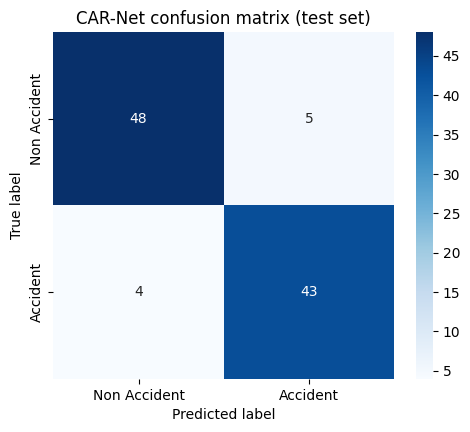

True Negatives  (Non_Accident predicted as Non_Accident): 48
False Positives (Non_Accident predicted as Accident)    : 5  -> false alarms
False Negatives (Accident predicted as Non_Accident)    : 4  -> MISSED accidents
True Positives  (Accident predicted as Accident)        : 43

Why false negatives matter most: a missed accident (FN) means no alert and delayed emergency response,
which can cost lives. A false positive (FP) causes a false alarm and wasted effort, which is costly but
less dangerous. That is why recall of the Accident class is monitored, and why the threshold and the
consecutive-hit logic are tuned to keep false alarms low WITHOUT sacrificing recall.


In [ ]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("CAR-Net confusion matrix (test set)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

print(f"True Negatives  (Non_Accident predicted as Non_Accident): {tn}")
print(f"False Positives (Non_Accident predicted as Accident)    : {fp}  -> false alarms")
print(f"False Negatives (Accident predicted as Non_Accident)    : {fn}  -> MISSED accidents")
print(f"True Positives  (Accident predicted as Accident)        : {tp}")
print("""
Why false negatives matter most: a missed accident (FN) means no alert and delayed emergency response,
which can cost lives. A false positive (FP) causes a false alarm and wasted effort, which is costly but
less dangerous. That is why recall of the Accident class is monitored, and why the threshold and the
consecutive-hit logic are tuned to keep false alarms low WITHOUT sacrificing recall.""")

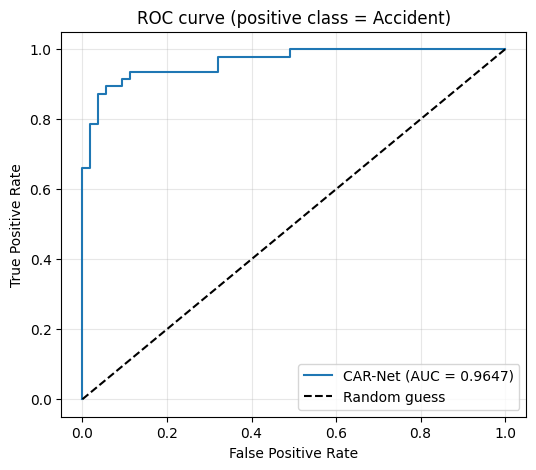

In [ ]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob_accident, pos_label=ACCIDENT)   # Accident = positive class
roc_auc = roc_auc_score(y_test, test_prob_accident)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"CAR-Net (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.title("ROC curve (positive class = Accident)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(f"ROC-AUC (test, Accident = positive class): {roc_auc:.4f}")

ROC-AUC (test, Accident = positive class): 0.9647


Accident class -> Precision: 0.8958 | Recall: 0.9149 | F1: 0.9053 | F2 (recall-weighted): 0.9110 | Average precision: 0.9669
Overall accuracy: 0.9100


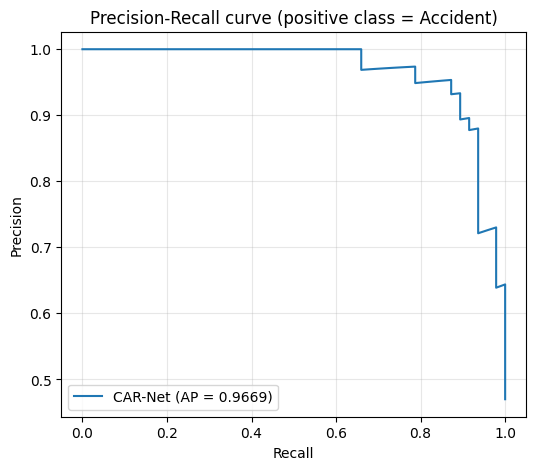

Why recall matters for accident detection: recall = TP / (TP + FN) is the fraction of real accidents
that the system actually catches. High accuracy alone can hide missed accidents (especially with imbalance).
Precision tells how many alerts are real. A good system keeps recall high first, then raises precision with
thresholding and consecutive-hit confirmation.


In [ ]:
prec, rec, f1, _ = precision_recall_fscore_support(y_test, test_pred, labels=[ACCIDENT], zero_division=0)
f2 = fbeta_score(y_test, test_pred, beta=2, pos_label=ACCIDENT, zero_division=0)
ap = average_precision_score(y_test, test_prob_accident)
print(f"Accident class -> Precision: {prec[0]:.4f} | Recall: {rec[0]:.4f} | F1: {f1[0]:.4f} | "
      f"F2 (recall-weighted): {f2:.4f} | Average precision: {ap:.4f}")
print(f"Overall accuracy: {accuracy_score(y_test, test_pred):.4f}")

pr_p, pr_r, _ = precision_recall_curve(y_test, test_prob_accident, pos_label=ACCIDENT)
plt.figure(figsize=(6, 5))
plt.plot(pr_r, pr_p, label=f"CAR-Net (AP = {ap:.4f})")
plt.title("Precision-Recall curve (positive class = Accident)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

print("""Why recall matters for accident detection: recall = TP / (TP + FN) is the fraction of real accidents
that the system actually catches. High accuracy alone can hide missed accidents (especially with imbalance).
Precision tells how many alerts are real. A good system keeps recall high first, then raises precision with
thresholding and consecutive-hit confirmation.""")

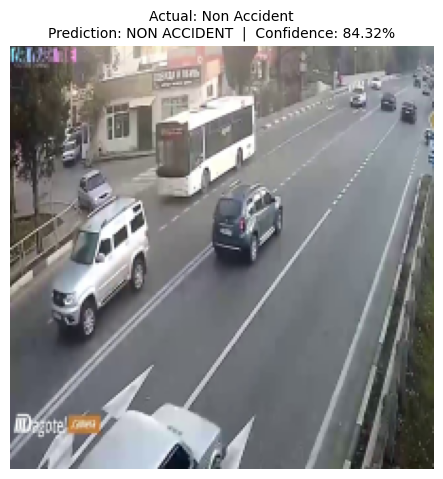

Prediction: NON ACCIDENT
Confidence: 84.32%
Accident Probability: 15.68%
Non-Accident Probability: 84.32%


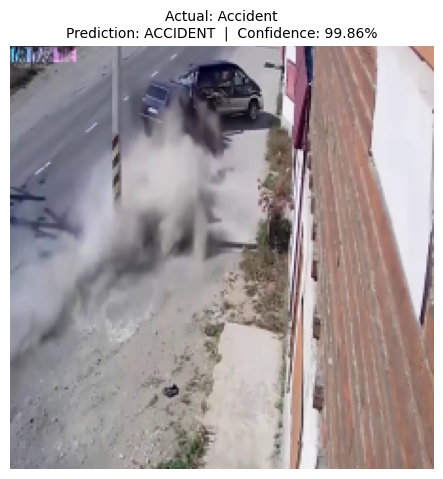

Prediction: ACCIDENT
Confidence: 99.86%
Accident Probability: 99.86%
Non-Accident Probability: 0.14%


In [ ]:
def predict_single_image(image_path, actual_label=None, show=True, model_to_use=None):
    """
    Predict one image with CAR-Net.
    actual_label (optional): 'Accident' / 'Non_Accident'. If omitted, it is inferred from the parent folder name
    when that folder is one of the class names.
    """
    m = model_to_use if model_to_use is not None else inference_model
    img, _ = preprocess_image(image_path)                    # identical preprocessing to training (BGR->RGB, 224x224, ...)
    batch = np.expand_dims(img, axis=0)                      # (1, 224, 224, 3)
    probs = m.predict(batch, verbose=0)[0]                   # [P(Non_Accident), P(Accident)]
    if probs.shape != (2,) or np.isnan(probs).any():
        raise RuntimeError(f"Invalid model output: {probs}")
    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx]) * 100
    result = {"image_path": image_path, "predicted_class": classes[pred_idx], "predicted_index": pred_idx,
              "confidence": confidence, "accident_probability": float(probs[ACCIDENT]),
              "non_accident_probability": float(probs[NON_ACCIDENT])}

    if actual_label is None:
        parent = os.path.basename(os.path.dirname(image_path))
        actual_label = parent if parent in classes else None
    result["actual_class"] = actual_label

    if show:
        plt.figure(figsize=(5.5, 5.5))
        plt.imshow(load_rgb_image(image_path))
        plt.axis("off")
        title = ""
        if actual_label is not None:
            title += f"Actual: {actual_label}\n"
        title += f"Prediction: {classes[pred_idx].upper()}  |  Confidence: {confidence:.2f}%"
        plt.title(title, fontsize=10)
        plt.show()
        print(f"Prediction: {classes[pred_idx].upper()}")
        print(f"Confidence: {confidence:.2f}%")
        print(f"Accident Probability: {probs[ACCIDENT] * 100:.2f}%")
        print(f"Non-Accident Probability: {probs[NON_ACCIDENT] * 100:.2f}%")
    return result


# Demo: one random test image per class
for c in classes:
    candidates = [p for p in test_paths if os.path.basename(os.path.dirname(p)) == c]
    _ = predict_single_image(random.choice(candidates))

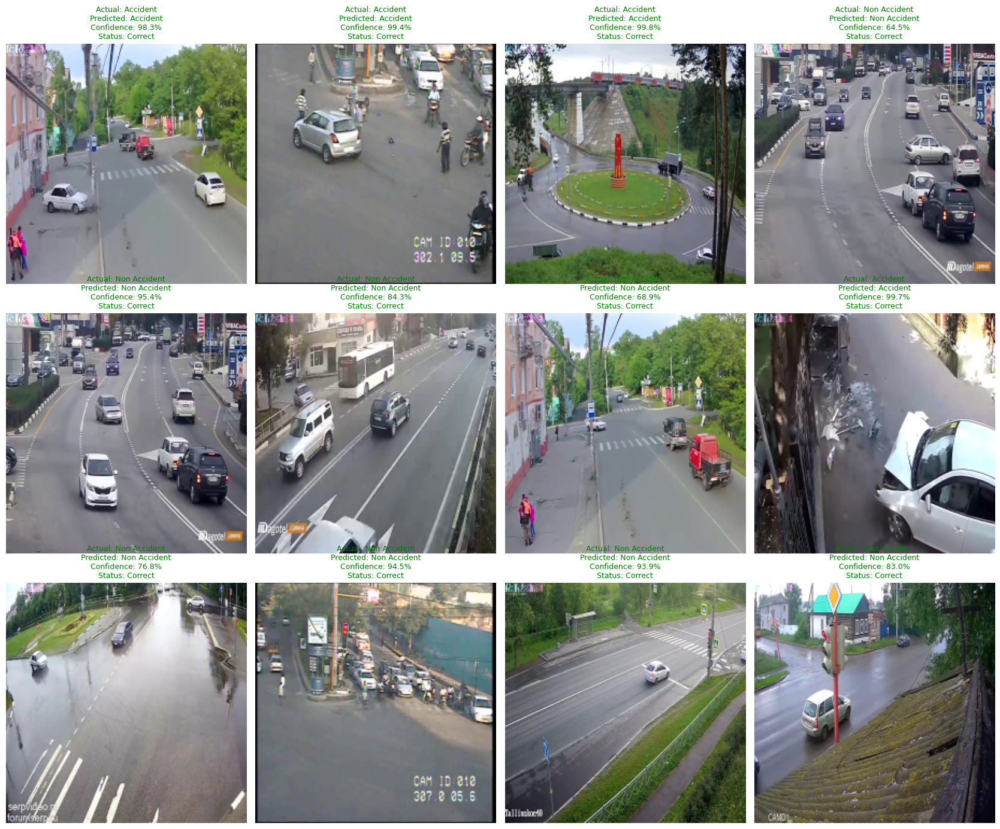

Wrong predictions only:


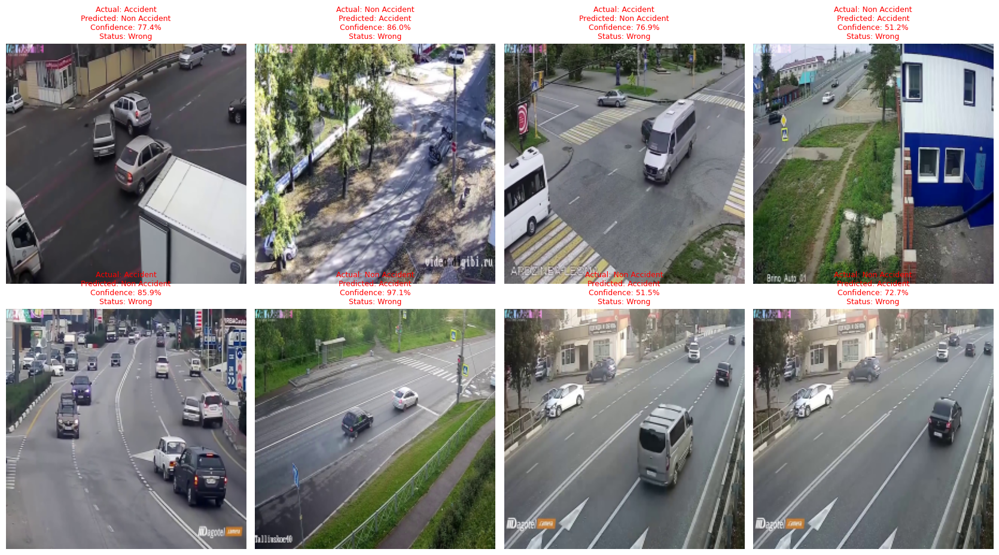

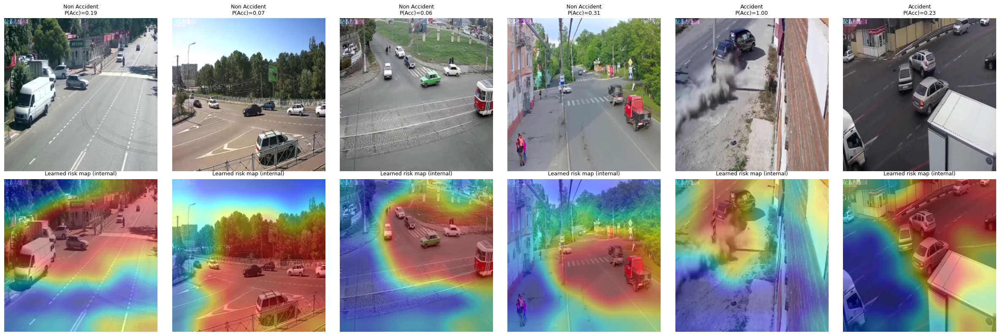

In [ ]:
def visualize_predictions(n_images=12, only_wrong=False, cols=4):
    """Show test images with Actual / Predicted / Confidence / Status. Green = correct, red = wrong."""
    idxs = np.arange(len(y_test))
    if only_wrong:
        idxs = idxs[test_pred != y_test]
        if len(idxs) == 0:
            print("No wrong predictions on the test set.")
            return
    rng = np.random.RandomState(SEED)
    chosen = rng.choice(idxs, size=min(n_images, len(idxs)), replace=False)
    rows_ = int(np.ceil(len(chosen) / cols))
    plt.figure(figsize=(4.2 * cols, 4.6 * rows_))
    for k, i in enumerate(chosen):
        ax = plt.subplot(rows_, cols, k + 1)
        ax.imshow(load_rgb_image(test_paths[i]))
        ax.axis("off")
        correct = test_pred[i] == y_test[i]
        conf = test_probs[i, test_pred[i]] * 100
        ax.set_title(f"Actual: {classes[y_test[i]]}\nPredicted: {classes[test_pred[i]]}\n"
                     f"Confidence: {conf:.1f}%\nStatus: {'Correct' if correct else 'Wrong'}",
                     fontsize=9, color="green" if correct else "red")
    plt.tight_layout()
    plt.show()


visualize_predictions(n_images=12)
print("Wrong predictions only:")
visualize_predictions(n_images=8, only_wrong=True)


def show_risk_maps(n_images=6):
    """Overlay the learned collision-risk map. It is an internal activation, NOT a ground-truth localisation."""
    try:
        risk_layer = best_model.get_layer("collision_risk_map")
    except ValueError:
        print("This model has no 'collision_risk_map' layer.")
        return
    viz_model = tf.keras.Model(best_model.input, [best_model.output, risk_layer.output])
    rng = np.random.RandomState(SEED + 1)
    chosen = rng.choice(len(y_test), size=min(n_images, len(y_test)), replace=False)
    plt.figure(figsize=(4 * n_images, 8))
    for k, i in enumerate(chosen):
        probs, risk = viz_model.predict(X_test[i:i + 1], verbose=0)
        risk = risk[0, :, :, 0]                                   # (7, 7)
        risk_up = cv2.resize(risk, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
        rgb = load_rgb_image(test_paths[i])
        heat = cv2.applyColorMap(np.uint8(255 * np.clip(risk_up, 0, 1)), cv2.COLORMAP_JET)
        heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(rgb, 0.6, heat, 0.4, 0)
        plt.subplot(2, n_images, k + 1); plt.imshow(rgb); plt.axis("off")
        plt.title(f"{classes[y_test[i]]}\nP(Acc)={probs[0, ACCIDENT]:.2f}", fontsize=9)
        plt.subplot(2, n_images, n_images + k + 1); plt.imshow(overlay); plt.axis("off")
        plt.title("Learned risk map (internal)", fontsize=9)
    plt.tight_layout()
    plt.show()


show_risk_maps()

Validation-set threshold sweep:
 threshold  precision  recall     f1
      0.30     0.7544  0.9348 0.8350
      0.35     0.7679  0.9348 0.8431
      0.40     0.7818  0.9348 0.8515
      0.45     0.7818  0.9348 0.8515
      0.50     0.7963  0.9348 0.8600
      0.55     0.8200  0.8913 0.8542
      0.60     0.8367  0.8913 0.8632
      0.65     0.8333  0.8696 0.8511
      0.70     0.8333  0.8696 0.8511
      0.75     0.8864  0.8478 0.8667
      0.80     0.8810  0.8043 0.8409
      0.85     0.8889  0.6957 0.7805
      0.90     0.9091  0.6522 0.7595
      0.95     0.9310  0.5870 0.7200


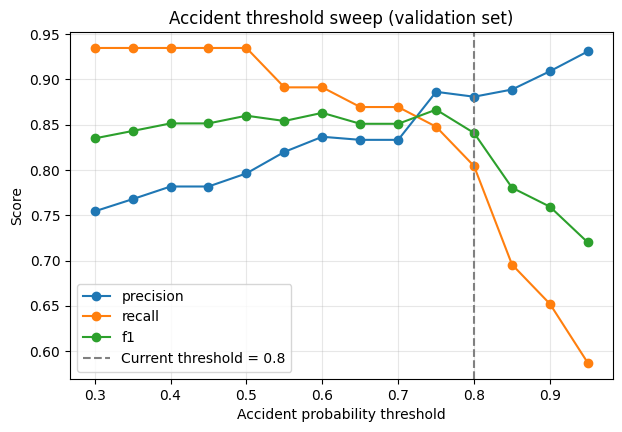


Test metrics at threshold 0.8: precision=0.9487, recall=0.7872, F1=0.8605
Set ACCIDENT_THRESHOLD (section 3) after choosing it from the VALIDATION sweep, then do not change it based on test results.


In [ ]:
def is_potential_accident(accident_probability, threshold=None):
    """A frame is a 'potential accident' only if P(Accident) >= threshold (not merely argmax == Accident)."""
    thr = ACCIDENT_THRESHOLD if threshold is None else threshold
    return float(accident_probability) >= thr


# The threshold can be optimised on VALIDATION data (never on the test set). This sweep uses real predictions.
val_prob_accident = val_probs[:, ACCIDENT]
sweep_rows = []
for thr in np.arange(0.30, 0.96, 0.05):
    pred_thr = (val_prob_accident >= thr).astype(int)
    sweep_rows.append({"threshold": round(float(thr), 2),
                       "precision": precision_score(y_val, pred_thr, pos_label=1, zero_division=0),
                       "recall": recall_score(y_val, pred_thr, pos_label=1, zero_division=0),
                       "f1": f1_score(y_val, pred_thr, pos_label=1, zero_division=0)})
threshold_df = pd.DataFrame(sweep_rows)
print("Validation-set threshold sweep:")
print(threshold_df.round(4).to_string(index=False))

plt.figure(figsize=(7, 4.5))
for col in ["precision", "recall", "f1"]:
    plt.plot(threshold_df["threshold"], threshold_df[col], marker="o", label=col)
plt.axvline(ACCIDENT_THRESHOLD, color="gray", linestyle="--", label=f"Current threshold = {ACCIDENT_THRESHOLD}")
plt.title("Accident threshold sweep (validation set)")
plt.xlabel("Accident probability threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

test_pred_thr = (test_prob_accident >= ACCIDENT_THRESHOLD).astype(int)
print(f"\nTest metrics at threshold {ACCIDENT_THRESHOLD}: "
      f"precision={precision_score(y_test, test_pred_thr, zero_division=0):.4f}, "
      f"recall={recall_score(y_test, test_pred_thr, zero_division=0):.4f}, "
      f"F1={f1_score(y_test, test_pred_thr, zero_division=0):.4f}")
print("Set ACCIDENT_THRESHOLD (section 3) after choosing it from the VALIDATION sweep, then do not change it based on test results.")

In [ ]:
class AccidentDebouncer:
    """Confirms an accident only after N consecutive frames with P(Accident) >= threshold."""

    def __init__(self, threshold=ACCIDENT_THRESHOLD, required_hits=REQUIRED_CONSECUTIVE_HITS):
        if not (0.0 < threshold < 1.0):
            raise ValueError("threshold must be between 0 and 1")
        if required_hits < 1:
            raise ValueError("required_hits must be >= 1")
        self.threshold = threshold
        self.required_hits = required_hits
        self.reset()

    def reset(self):
        self.hit_count = 0
        self.alert_active = False
        self.recent_probs = deque(maxlen=self.required_hits)

    def update(self, accident_probability):
        """Feed one frame-level probability. Returns a dict describing the current decision state."""
        p = float(accident_probability)
        is_hit = p >= self.threshold
        if is_hit:
            self.hit_count += 1
            self.recent_probs.append(p)
        else:
            self.hit_count = 0            # any non-hit RESETS the counter
            self.recent_probs.clear()
            self.alert_active = False
        confirmed = self.hit_count >= self.required_hits
        new_alert = confirmed and not self.alert_active    # fire the alert once per event, not on every frame
        if confirmed:
            self.alert_active = True
        mean_conf = float(np.mean(self.recent_probs)) if self.recent_probs else 0.0
        return {"probability": p, "is_hit": is_hit, "consecutive_hits": self.hit_count,
                "confirmed": confirmed, "new_alert": new_alert, "mean_confidence": mean_conf}


def run_debounce_demo(probabilities, title):
    print(f"\n--- {title} ---")
    deb = AccidentDebouncer()
    for i, p in enumerate(probabilities, start=1):
        s = deb.update(p)
        status = "ACCIDENT CONFIRMED" if s["confirmed"] else ("potential accident" if s["is_hit"] else "normal")
        print(f"Frame {i}: P(accident)={p:.2f} | hit={s['is_hit']} | consecutive={s['consecutive_hits']} | {status}")


# Illustrative sequences from the project description (hand-written values, NOT model results)
run_debounce_demo([0.91, 0.88, 0.94], "Three consecutive hits -> confirmed")
run_debounce_demo([0.91, 0.30, 0.94], "Accident / Non-Accident / Accident -> counter resets, no confirmation")



--- Three consecutive hits -> confirmed ---
Frame 1: P(accident)=0.91 | hit=True | consecutive=1 | potential accident
Frame 2: P(accident)=0.88 | hit=True | consecutive=2 | potential accident
Frame 3: P(accident)=0.94 | hit=True | consecutive=3 | ACCIDENT CONFIRMED

--- Accident / Non-Accident / Accident -> counter resets, no confirmation ---
Frame 1: P(accident)=0.91 | hit=True | consecutive=1 | potential accident
Frame 2: P(accident)=0.30 | hit=False | consecutive=0 | normal
Frame 3: P(accident)=0.94 | hit=True | consecutive=1 | potential accident


In [ ]:
ALERT_LOG = []


def log_to_file_handler(record):
    """Example handler: append the alert to a JSON-lines file. Replace/add handlers for SMS, e-mail, dashboard, FastAPI..."""
    with open(os.path.join(OUTPUT_DIR, "alerts.jsonl"), "a") as f:
        f.write(json.dumps(record) + "\n")


def trigger_accident_alert(confidence, source="image/video stream", frame_index=None, handlers=None):
    """
    Prototype alert stage. It only prints + logs. Real emergency-service calls are NOT implemented.
    `handlers` is a list of callables that receive the alert record, so the alert can later be connected to
    SMS, e-mail, a web dashboard, a FastAPI backend or an emergency-response system without changing this function.
    """
    record = {"status": "ACCIDENT CONFIRMED", "confidence_percent": round(float(confidence) * 100, 2),
              "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
              "source": source, "frame_index": frame_index,
              "action": "Emergency response required"}
    print("=" * 40)
    print("🚨 ACCIDENT ALERT")
    print("=" * 40)
    print(f"Status: {record['status']}")
    print(f"Confidence: {record['confidence_percent']:.2f}%")
    print(f"Time: {record['timestamp']}")
    print(f"Source: {source}" + (f" (frame {frame_index})" if frame_index is not None else ""))
    print(f"Action: {record['action']}")
    print("=" * 40)
    ALERT_LOG.append(record)
    for h in (handlers or []):
        try:
            h(record)
        except Exception as e:      # a failing handler must never hide the alert, but must be reported
            print(f"ALERT HANDLER ERROR ({getattr(h, '__name__', 'handler')}): {e}")
    return record


# Demo with the real model: feed 4 test accident images to the pipeline (frame-level prediction -> threshold -> debounce -> alert).
# NOTE: these are independent test images, not truly consecutive video frames. This only exercises the logic.
demo_paths = [p for p in test_paths if os.path.basename(os.path.dirname(p)) == "Accident"][:4]
deb_demo = AccidentDebouncer()
for k, pth in enumerate(demo_paths):
    res = predict_single_image(pth, show=False)
    st = deb_demo.update(res["accident_probability"])
    print(f"Image {k + 1}: P(accident)={res['accident_probability']:.3f} | consecutive hits={st['consecutive_hits']}")
    if st["new_alert"]:
        trigger_accident_alert(st["mean_confidence"], source="test-image demo", frame_index=k + 1,
                               handlers=[log_to_file_handler])


Image 1: P(accident)=0.994 | consecutive hits=1
Image 2: P(accident)=0.985 | consecutive hits=2
Image 3: P(accident)=0.997 | consecutive hits=3
🚨 ACCIDENT ALERT
Status: ACCIDENT CONFIRMED
Confidence: 99.21%
Time: 2026-10-06T18:16:51
Source: test-image demo (frame 3)
Action: Emergency response required
Image 4: P(accident)=0.998 | consecutive hits=4


In [ ]:
VIDEO_PATH = '/content/drive/MyDrive/Colab Notebooks/datasets/test_video.mp4'    # <-- change this
VIDEO_OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'car_net_video_output.mp4')
VIDEO_FRAME_STRIDE = 2      # classify every 2nd frame (the debouncer counts PROCESSED frames)


def run_video_inference(video_path, output_path=None, frame_stride=1, max_frames=None, model_to_use=None):
    m = model_to_use if model_to_use is not None else inference_model
    if not os.path.isfile(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"OpenCV could not open the video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = None
    if output_path:
        writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

    debouncer = AccidentDebouncer()
    records, alert_frames = [], []
    prob, state, frame_idx = 0.0, {"consecutive_hits": 0, "confirmed": False, "is_hit": False}, 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if max_frames is not None and frame_idx >= max_frames:
            break
        if frame_idx % frame_stride == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)                       # BGR -> RGB
            rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            x = tf.keras.applications.efficientnet.preprocess_input(rgb.astype(np.float32))
            prob = float(m(np.expand_dims(x, 0), training=False).numpy()[0, ACCIDENT])   # frame-level classification
            state = debouncer.update(prob)                                      # temporal decision layer
            records.append({"frame": frame_idx, "accident_probability": prob,
                            "consecutive_hits": state["consecutive_hits"], "confirmed": state["confirmed"]})
            if state["new_alert"]:
                trigger_accident_alert(state["mean_confidence"], source=os.path.basename(video_path),
                                       frame_index=frame_idx, handlers=[log_to_file_handler])
                alert_frames.append(frame.copy())

        if state["confirmed"]:
            status, color = "ACCIDENT", (0, 0, 255)
        elif state["is_hit"]:
            status, color = f"POTENTIAL ACCIDENT ({state['consecutive_hits']}/{REQUIRED_CONSECUTIVE_HITS})", (0, 165, 255)
        else:
            status, color = "NORMAL", (0, 180, 0)
        cv2.rectangle(frame, (0, 0), (min(width, 560), 70), (0, 0, 0), -1)
        cv2.putText(frame, f"ACCIDENT PROBABILITY: {prob * 100:.1f}%", (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(frame, f"STATUS: {status}", (10, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        if writer is not None:
            writer.write(frame)
        frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    print(f"Processed {frame_idx} frames; {len(records)} classified; alerts raised: {len(alert_frames)}")
    return pd.DataFrame(records), alert_frames


if os.path.isfile(VIDEO_PATH):
    video_df, video_alert_frames = run_video_inference(VIDEO_PATH, VIDEO_OUTPUT_PATH, frame_stride=VIDEO_FRAME_STRIDE)
    plt.figure(figsize=(10, 4))
    plt.plot(video_df["frame"], video_df["accident_probability"], label="Accident probability")
    plt.axhline(ACCIDENT_THRESHOLD, color="red", linestyle="--", label="Threshold")
    plt.title("Frame-level accident probability over the video")
    plt.xlabel("Frame index")
    plt.ylabel("P(Accident)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    for k, fr in enumerate(video_alert_frames[:3]):
        plt.figure(figsize=(7, 4)); plt.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)); plt.axis("off")
        plt.title(f"Frame at alert #{k + 1}"); plt.show()
    print("Annotated video saved to:", VIDEO_OUTPUT_PATH)
    print("If the video does not play in a browser, re-encode it:  !ffmpeg -y -i <in.mp4> -vcodec libx264 <out.mp4>")
else:
    print(f"[Video section skipped] No video found at: {VIDEO_PATH}\n"
          "Upload a traffic video to Drive and set VIDEO_PATH, then re-run this cell.")



[Video section skipped] No video found at: /content/drive/MyDrive/Colab Notebooks/datasets/test_video.mp4
Upload a traffic video to Drive and set VIDEO_PATH, then re-run this cell.


In [ ]:
ft_model.save(FINAL_MODEL_PATH)
print("Saved:", FINAL_MODEL_PATH)
if os.path.isfile(BEST_MODEL_PATH):
    print("Saved:", BEST_MODEL_PATH)
else:
    raise FileNotFoundError("best_car_net.keras is missing - the checkpoint was never written.")

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump({"class_names": classes, "class_to_index": CLASS_TO_IDX,
               "note": "index 0 = Non_Accident, index 1 = Accident"}, f, indent=2)
print("Saved:", CLASS_NAMES_PATH)

with open(HISTORY_PATH, "w") as f:
    json.dump({"initial_training": {k: [float(v) for v in vals] for k, vals in history_stage1.history.items()},
               "fine_tuning": {k: [float(v) for v in vals] for k, vals in history_stage2.history.items()},
               "settings": {"seed": SEED, "batch_size": BATCH_SIZE, "initial_lr": INITIAL_LR,
                            "fine_tune_lr": FINE_TUNE_LR, "fine_tune_last_n": FINE_TUNE_LAST_N,
                            "class_weights": class_weight_dict}}, f, indent=2)
print("Saved:", HISTORY_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs/final_car_net.keras
Saved: /content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs/best_car_net.keras
Saved: /content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs/class_names.json
Saved: /content/drive/MyDrive/Colab Notebooks/CAR_Net_outputs/training_history.json


Loaded class names: ['Non Accident', 'Accident']
Max prediction difference (in-memory vs loaded): 0.0


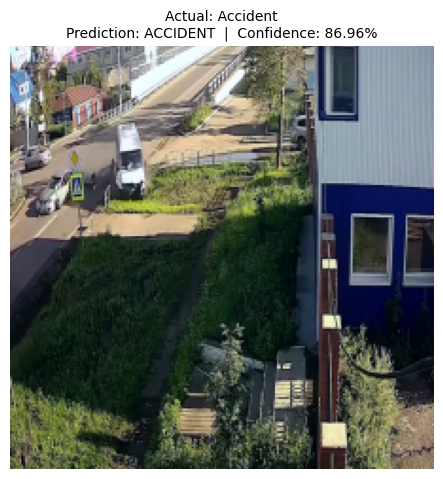

Prediction: ACCIDENT
Confidence: 86.96%
Accident Probability: 86.96%
Non-Accident Probability: 13.04%


In [ ]:
loaded_model = load_car_net_model(FINAL_MODEL_PATH)
with open(CLASS_NAMES_PATH) as f:
    loaded_classes = json.load(f)["class_names"]
print("Loaded class names:", loaded_classes)

# Consistency check: the reloaded model must reproduce the in-memory predictions
check_imgs = X_test[:8]
p_mem = ft_model.predict(check_imgs, verbose=0)
p_loaded = loaded_model.predict(check_imgs, verbose=0)
print("Max prediction difference (in-memory vs loaded):", float(np.max(np.abs(p_mem - p_loaded))))
assert np.allclose(p_mem, p_loaded, atol=1e-4), "Reloaded model does not match the original!"

sample_path = random.choice(list(test_paths))
_ = predict_single_image(sample_path, model_to_use=loaded_model)


In [ ]:
RUN_ABLATION = True
ABLATION_EPOCHS = 30

ABLATION_CONFIGS = [
    ("EfficientNet-B0 (baseline)", dict(use_multiscale=False, use_spatial=False, use_relation=False, use_risk=False, use_fusion=False)),
    ("+ Multi-Scale",              dict(use_multiscale=True,  use_spatial=False, use_relation=False, use_risk=False, use_fusion=False)),
    ("+ Spatial Region",           dict(use_multiscale=True,  use_spatial=True,  use_relation=False, use_risk=False, use_fusion=False)),
    ("+ Collision Relation",       dict(use_multiscale=True,  use_spatial=True,  use_relation=True,  use_risk=False, use_fusion=False)),
    ("+ Risk Map",                 dict(use_multiscale=True,  use_spatial=True,  use_relation=True,  use_risk=True,  use_fusion=False)),
    ("CAR-Net (+ Fusion)",         dict(use_multiscale=True,  use_spatial=True,  use_relation=True,  use_risk=True,  use_fusion=True)),
]

ABLATION_COLUMNS = ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Parameters"]
ablation_df = pd.DataFrame([[name, "", "", "", "", "", ""] for name, _ in ABLATION_CONFIGS], columns=ABLATION_COLUMNS)
print("Ablation table template (empty until the study is run):")
print(ablation_df.to_string(index=False))


def run_ablation():
    results = []
    for name, cfg in ABLATION_CONFIGS:
        print("\n" + "=" * 70 + f"\nTraining ablation variant: {name}\n" + "=" * 70)
        random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
        m = build_car_net(name="ablation_model", **cfg)
        compile_model(m, INITIAL_LR)
        h = m.fit(make_dataset(X_train, y_train, training=True), validation_data=val_ds,
                  epochs=ABLATION_EPOCHS, class_weight=class_weight_dict,
                  callbacks=make_callbacks(None), verbose=0)
        check_history_for_nan(h)
        probs = m.predict(test_ds, verbose=0)[:, ACCIDENT]
        pred = (probs >= 0.5).astype(int)
        total, trainable, _ = count_params(m)
        results.append({"Model": name,
                        "Accuracy": accuracy_score(y_test, pred),
                        "Precision": precision_score(y_test, pred, zero_division=0),
                        "Recall": recall_score(y_test, pred, zero_division=0),
                        "F1": f1_score(y_test, pred, zero_division=0),
                        "ROC-AUC": roc_auc_score(y_test, probs),
                        "Parameters": total})
        print(f"{name}: acc={results[-1]['Accuracy']:.4f}, recall={results[-1]['Recall']:.4f}, "
              f"auc={results[-1]['ROC-AUC']:.4f}, params={total:,}")
        del m
        gc.collect()
    df = pd.DataFrame(results, columns=ABLATION_COLUMNS)
    df.to_csv(os.path.join(OUTPUT_DIR, "ablation_results.csv"), index=False)
    return df


if RUN_ABLATION:
    ablation_df = run_ablation()
    print("\nAblation results (test set, threshold 0.5, frozen backbone for all variants):")
    print(ablation_df.round(4).to_string(index=False))
else:
    print("\nRUN_ABLATION is False -> ablation not executed. Set it to True to fill the table.")


Ablation table template (empty until the study is run):
                     Model Accuracy Precision Recall F1 ROC-AUC Parameters
EfficientNet-B0 (baseline)                                                
             + Multi-Scale                                                
          + Spatial Region                                                
      + Collision Relation                                                
                + Risk Map                                                
        CAR-Net (+ Fusion)                                                

Training ablation variant: EfficientNet-B0 (baseline)

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 23: ReduceLROnPlateau reducing learning rate to 4.500000213738531e-05.

Epoch 26: ReduceLROnPlateau reducing learning rate to 1.3500000204658135e-05.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 20.


EfficientNet-B0 (baseline): acc=0.8800, recall=0.8298, auc=0.9514, params=4,213,797

Training ablation variant: + Multi-Scale

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.500000213738531e-05.

Epoch 15: ReduceLROnPlateau reducing learning rate to 1.3500000204658135e-05.
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 9.
+ Multi-Scale: acc=0.9000, recall=0.8298, auc=0.9839, params=4,543,269

Training ablation variant: + Spatial Region

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.500000213738531e-05.

Epoch 22: ReduceLROnPlateau reducing learning rate to 1.3500000204658135e-05.

Epoch 25: ReduceLROnPlateau reducing learning rate to 4.050000006827758e-06.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 19.
+ Spatial Region: acc=0.9300, recall=0.9362